In [5]:
## SparkSession = ponto de entrada PySpark, aqui configuramos driver JDBC no PostgreSQL pra subir infos no final do pipe
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import *

spark = (
    SparkSession.builder
    .appName("FraudDetectionAnalysis")
    ## driver JDBC do Dockerfile
    .config("spark.jars", "/usr/local/spark/jars/postgresql-42.7.1.jar")
    ## aumenta o timeout do driver para queries pesadas
    .config("spark.sql.shuffle.partitions", "50")
    ## adaptive query execution — Spark 3.x otimiza joins auto
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)

## Acessa http://localhost:4040 - Spark UI jobs rodando real time
print(f"Spark version: {spark.version}")
print(f"Spark UI: http://localhost:4040")

Spark version: 3.5.0
Spark UI: http://localhost:4040


In [9]:
## Schema explícito = Spark faz a leitura em uma passada só, evitando o schema inference que leria o arquivo inteiro duas vezes — desperdício de I/O

## _c0 é o índice gerado pelo Kaggle — incluímos no schema para não quebrar a leitura, e vamos dropar logo após a ingestão
schema = StructType([
    StructField("_c0",                  IntegerType(),  True),  ## índice Kaggle — será dropado
    StructField("trans_date_trans_time",TimestampType(),True),
    StructField("cc_num",               LongType(),     True),
    StructField("merchant",             StringType(),   True),
    StructField("category",             StringType(),   True),
    StructField("amt",                  DoubleType(),   True),
    StructField("first",                StringType(),   True),
    StructField("last",                 StringType(),   True),
    StructField("gender",               StringType(),   True),
    StructField("street",               StringType(),   True),
    StructField("city",                 StringType(),   True),
    StructField("state",                StringType(),   True),
    StructField("zip",                  IntegerType(),  True),
    StructField("lat",                  DoubleType(),   True),
    StructField("long",                 DoubleType(),   True),
    StructField("city_pop",             IntegerType(),  True),
    StructField("job",                  StringType(),   True),
    StructField("dob",                  DateType(),     True),
    StructField("trans_num",            StringType(),   True),
    StructField("unix_time",            IntegerType(),  True),
    StructField("merch_lat",            DoubleType(),   True),
    StructField("merch_long",           DoubleType(),   True),
    StructField("is_fraud",             IntegerType(),  True),
])

from pyspark.sql.types import TimestampType, DateType

df_raw = (
    spark.read
    .option("header", "true")
    .option("mode", "PERMISSIVE")   ## PERMISSIVE mantém linhas com problemas como nulo
                                    ## DROPMALFORMED descartava tudo pois _c0 não estava no schema
    .schema(schema)
    .csv("/home/jovyan/data/fraudTrain.csv")
    .drop("_c0")                    ## remove o índice do Kaggle — não tem valor analítico
)

## cache() mantém o DataFrame em memória — evita reler o CSV a cada operação
## só faz sentido quando você vai usar o df várias vezes na mesma sessão
df_raw.cache()

print(f"Total de transações: {df_raw.count():,}")
print(f"Partições:           {df_raw.rdd.getNumPartitions()}")
df_raw.printSchema()
## esperado: Total de transações: 1,296,675 — Partições: 8

Total de transações: 1,296,675
Partições:           12
root
 |-- trans_date_trans_time: timestamp (nullable = true)
 |-- cc_num: long (nullable = true)
 |-- merchant: string (nullable = true)
 |-- category: string (nullable = true)
 |-- amt: double (nullable = true)
 |-- first: string (nullable = true)
 |-- last: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip: integer (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- city_pop: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- dob: date (nullable = true)
 |-- trans_num: string (nullable = true)
 |-- unix_time: integer (nullable = true)
 |-- merch_lat: double (nullable = true)
 |-- merch_long: double (nullable = true)
 |-- is_fraud: integer (nullable = true)



In [10]:
## Story-telling do case = Desvio de verba 

## Distribuição de fraude — é o dataset desbalanceado? (spoiler: muito)
print("=== Distribuição de fraude ===")
df_raw.groupBy("is_fraud").count().show()

# Categorias com mais transações
print("=== Top 10 categorias ===")
(df_raw
 .groupBy("category")
 .agg(
     F.count("*").alias("total_transacoes"),
     F.round(F.sum("amt"), 2).alias("volume_total_usd"),
     F.round(F.avg("amt"), 2).alias("ticket_medio_usd")
 )
 .orderBy(F.desc("total_transacoes"))
 .show(10)
)

# Estatísticas de valor
print("=== Estatísticas de valor (amt) ===")
df_raw.select("amt").describe().show()

## 0,58% de fraude

=== Distribuição de fraude ===
+--------+-------+
|is_fraud|  count|
+--------+-------+
|       0|1289169|
|       1|   7506|
+--------+-------+

=== Top 10 categorias ===
+--------------+----------------+----------------+----------------+
|      category|total_transacoes|volume_total_usd|ticket_medio_usd|
+--------------+----------------+----------------+----------------+
| gas_transport|          131659|      8351732.29|           63.43|
|   grocery_pos|          123638|   1.446082238E7|          116.96|
|          home|          123115|      7173928.11|           58.27|
|  shopping_pos|          116672|      9307993.61|           79.78|
|     kids_pets|          113035|      6503680.16|           57.54|
|  shopping_net|           97543|      8625149.68|           88.42|
| entertainment|           94014|      6036678.56|           64.21|
|   food_dining|           91461|      4672459.44|           51.09|
| personal_care|           90758|      4353450.53|           47.97|
|health_fitn

In [11]:
## Transformação de dados
df_clean = (
    df_raw
    ## converte string para timestamp — fundamental para análises temporais
    ## já veio como TimestampType do schema — cast direto sem parsing de formato
    .withColumn(
        "trans_timestamp",
        F.col("trans_date_trans_time")
    )
    ## extrai componentes de data para análise temporal (hora dia, dia semana)
    .withColumn("trans_hour",        F.hour("trans_timestamp"))
    .withColumn("trans_day_of_week", F.dayofweek("trans_timestamp"))
    .withColumn("trans_month",       F.month("trans_timestamp"))
    .withColumn("trans_year",        F.year("trans_timestamp"))
    ## converte data de nascimento para calcular idade
    ## já veio como DateType do schema — sem conversão necessária
    .withColumn("dob_date",          F.col("dob"))
    .withColumn(
        "age",
        (F.datediff(F.current_date(), F.col("dob_date")) / 365).cast(IntegerType())
    )
    ## distância geográfica entre portador e merchant (distância euclidiana = ponto A a ponto B)
    .withColumn(
        "dist_km",
        F.round(
            F.sqrt(
                F.pow(F.col("lat") - F.col("merch_lat"), 2) +
                F.pow(F.col("long") - F.col("merch_long"), 2)
            ) * 111,  ## 1 grau ≈ 111 km
            2
        )
    )
    ## segmenta valor em faixas para análise de risco
    .withColumn(
        "amt_segment",
        F.when(F.col("amt") < 10,   "micro")
         .when(F.col("amt") < 50,   "baixo")
         .when(F.col("amt") < 200,  "medio")
         .when(F.col("amt") < 1000, "alto")
         .otherwise("premium")
    )
    ## remove colunas desnecessárias
    .drop("street", "zip", "trans_date_trans_time", "dob", "unix_time")
    ## remove linhas com valores null em colunas críticas para a análise
    .dropna(subset=["amt", "is_fraud", "category", "trans_timestamp"])
)

df_clean.cache()
print(f"Registros após limpeza: {df_clean.count():,}")
df_clean.printSchema()

Registros após limpeza: 1,296,675
root
 |-- cc_num: long (nullable = true)
 |-- merchant: string (nullable = true)
 |-- category: string (nullable = true)
 |-- amt: double (nullable = true)
 |-- first: string (nullable = true)
 |-- last: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- city_pop: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- trans_num: string (nullable = true)
 |-- merch_lat: double (nullable = true)
 |-- merch_long: double (nullable = true)
 |-- is_fraud: integer (nullable = true)
 |-- trans_timestamp: timestamp (nullable = true)
 |-- trans_hour: integer (nullable = true)
 |-- trans_day_of_week: integer (nullable = true)
 |-- trans_month: integer (nullable = true)
 |-- trans_year: integer (nullable = true)
 |-- dob_date: date (nullable = true)
 |-- age: integer (nullable = true)
 |-- dist_

In [15]:
## JOINS = Enriquecer o dataset principal na criacao da tabela de referência
## Tabela de referência — simula um dado dimensional real (ex: vindo de um DW)
category_risk = spark.createDataFrame([
    ("grocery_pos",       "Supermercado",        1),
    ("grocery_net",       "Supermercado Online", 3),  ## categoria ausente no dataset — adicionada
    ("shopping_net",      "E-commerce",          3),
    ("misc_net",          "Internet geral",      4),
    ("entertainment",     "Entretenimento",      2),
    ("gas_transport",     "Combustível",         2),
    ("food_dining",       "Alimentação",         1),
    ("personal_care",     "Cuidados pessoais",   1),
    ("health_fitness",    "Saúde",               1),
    ("travel",            "Viagem",              3),
    ("kids_pets",         "Crianças e pets",     1),
    ("home",              "Casa",                2),
    ("shopping_pos",      "Varejo físico",       2),
    ("misc_pos",          "PDV geral",           2),
], ["category", "category_label", "risk_score"])

## Broadcast join = quando uma tabela é pequena, o Spark a envia para
## todos os workers em memória, evitando o shuffle custoso de um join comum
df_enriched = df_clean.join(
    F.broadcast(category_risk),
    on="category",
    how="left"
)

## Valida que o join não perdeu registros no caminho
print(f"Antes do join:                 {df_clean.count():,}")
print(f"Depois do join:                {df_enriched.count():,}")
print(f"Nulos em risk_score após join: {df_enriched.filter(F.col('risk_score').isNull()).count():,}")

Antes do join:                 1,296,675
Depois do join:                1,296,675
Nulos em risk_score após join: 0


In [16]:
## Window functions = calcular métricas por grupo mantendo o nível de linha 

## Janela por cartão de crédito, ordenada por tempo
window_by_card = Window.partitionBy("cc_num").orderBy("trans_timestamp")

## Janela por cartão nos últimos 7 dias
window_7d = (
    Window
    .partitionBy("cc_num")
    .orderBy(F.unix_timestamp("trans_timestamp"))
    .rangeBetween(-7 * 86400, 0)  # 7 dias em segundos
)

df_windowed = (
    df_enriched
    ## número sequencial da transação por cartão — cartões muito ativos
    .withColumn("trans_seq",        F.row_number().over(window_by_card))
    ## valor acumulado por cartão
    .withColumn("amt_cumsum",       F.sum("amt").over(window_by_card))
    ## valor da transação anterior no mesmo cartão — saltos bruscos
    .withColumn("prev_amt",         F.lag("amt", 1).over(window_by_card))
    ## variação percentual em relação à transação anterior
    .withColumn(
        "amt_pct_change",
        F.round(
            (F.col("amt") - F.col("prev_amt")) / F.col("prev_amt") * 100,
            2
        )
    )
    ## total de transações nos últimos 7 dias mesmo cartão
    .withColumn("trans_count_7d",   F.count("*").over(window_7d))
    ## volume financeiro últimos 7 dias
    .withColumn("amt_sum_7d",       F.round(F.sum("amt").over(window_7d), 2))
    ## média móvel de 7 dias
    .withColumn("amt_avg_7d",       F.round(F.avg("amt").over(window_7d), 2))
)

print("Window functions aplicadas. Amostra:")
(df_windowed
 .select("cc_num", "trans_timestamp", "amt", "prev_amt",
         "amt_pct_change", "trans_count_7d", "amt_avg_7d")
 .filter(F.col("trans_seq") > 1)
 .show(5, truncate=False)
)

Window functions aplicadas. Amostra:
+------------+-------------------+-----+--------+--------------+--------------+----------+
|cc_num      |trans_timestamp    |amt  |prev_amt|amt_pct_change|trans_count_7d|amt_avg_7d|
+------------+-------------------+-----+--------+--------------+--------------+----------+
|573860193545|2019-01-01 13:48:43|18.48|40.8    |-54.71        |2             |29.64     |
|573860193545|2019-01-01 13:52:50|87.91|18.48   |375.7         |3             |49.06     |
|573860193545|2019-01-01 17:51:51|25.67|87.91   |-70.8         |4             |43.22     |
|573860193545|2019-01-01 19:35:11|46.28|25.67   |80.29         |5             |43.83     |
|573860193545|2019-01-01 22:20:11|1.36 |46.28   |-97.06        |6             |36.75     |
+------------+-------------------+-----+--------+--------------+--------------+----------+
only showing top 5 rows



In [17]:
## Storytelling dos dados.


## Pergunta 1: Quais categorias concentram a fraude?
print("=== Fraude por categoria ===")
fraud_by_category = (
    df_windowed
    .groupBy("category", "category_label", "risk_score")
    .agg(
        F.count("*").alias("total_trans"),
        F.sum("is_fraud").alias("total_fraud"),
        F.round(F.sum("is_fraud") / F.count("*") * 100, 3).alias("fraud_rate_pct"),
        F.round(F.avg(F.when(F.col("is_fraud") == 1, F.col("amt"))), 2).alias("avg_fraud_amt"),
        F.round(F.sum(F.when(F.col("is_fraud") == 1, F.col("amt"))), 2).alias("total_fraud_usd")
    )
    .orderBy(F.desc("fraud_rate_pct"))
)
fraud_by_category.show(truncate=False)

## Pergunta 2: Fraude por hora do dia 
print("=== Fraude por hora do dia ===")
fraud_by_hour = (
    df_windowed
    .groupBy("trans_hour")
    .agg(
        F.count("*").alias("total_trans"),
        F.sum("is_fraud").alias("total_fraud"),
        F.round(F.sum("is_fraud") / F.count("*") * 100, 3).alias("fraud_rate_pct")
    )
    .orderBy("trans_hour")
)
fraud_by_hour.show(24)

## Pergunta 3: Perfil demográfico da fraude 
print("=== Fraude por faixa etária e gênero ===")
fraud_by_demo = (
    df_windowed
    .withColumn(
        "age_group",
        F.when(F.col("age") < 30, "18-29")
         .when(F.col("age") < 45, "30-44")
         .when(F.col("age") < 60, "45-59")
         .otherwise("60+")
    )
    .groupBy("age_group", "gender")
    .agg(
        F.count("*").alias("total_trans"),
        F.sum("is_fraud").alias("total_fraud"),
        F.round(F.sum("is_fraud") / F.count("*") * 100, 3).alias("fraud_rate_pct"),
        F.round(F.avg("amt"), 2).alias("avg_ticket")
    )
    .orderBy("age_group", "gender")
)
fraud_by_demo.show()

## Pergunta 4: Estados com maior volume de fraude 
print("=== Top 10 estados por fraude ===")
fraud_by_state = (
    df_windowed
    .groupBy("state")
    .agg(
        F.sum("is_fraud").alias("total_fraud"),
        F.round(F.sum("is_fraud") / F.count("*") * 100, 3).alias("fraud_rate_pct"),
        F.round(F.sum(F.when(F.col("is_fraud") == 1, F.col("amt"))), 2).alias("total_fraud_usd")
    )
    .orderBy(F.desc("total_fraud_usd"))
)
fraud_by_state.show(10)

=== Fraude por categoria ===
+--------------+-------------------+----------+-----------+-----------+--------------+-------------+---------------+
|category      |category_label     |risk_score|total_trans|total_fraud|fraud_rate_pct|avg_fraud_amt|total_fraud_usd|
+--------------+-------------------+----------+-----------+-----------+--------------+-------------+---------------+
|shopping_net  |E-commerce         |3         |97543      |1713       |1.756         |999.25       |1711723.71     |
|misc_net      |Internet geral     |4         |63287      |915        |1.446         |797.01       |729266.76      |
|grocery_pos   |Supermercado       |1         |123638     |1743       |1.41          |311.99       |543797.9       |
|shopping_pos  |Varejo físico      |2         |116672     |843        |0.723         |876.92       |739245.09      |
|gas_transport |Combustível        |2         |131659     |618        |0.469         |12.29        |7594.11        |
|misc_pos      |PDV geral          

In [26]:
## Parquet = formato colunar padrão do ecossistema de dados que permite que leituras futuras ignorem partições irrelevantes

## Seleciona colunas finais para persistir
df_final = (
    df_windowed
    .select(
        "trans_num", "trans_timestamp", "cc_num", "merchant",
        "category", "category_label", "risk_score",
        "amt", "amt_segment", "is_fraud",
        "city", "state", "lat", "long",
        "merch_lat", "merch_long", "dist_km",
        "age", "gender", "job",
        "trans_hour", "trans_day_of_week", "trans_month", "trans_year",
        "trans_seq", "amt_cumsum", "prev_amt", "amt_pct_change",
        "trans_count_7d", "amt_sum_7d", "amt_avg_7d"
    )
)

## Escreve em Parquet particionado por ano/mês, "show me fraud in January 2020", o Spark. vai direto para a pasta trans_year=2020/trans_month=1
(
    df_final
    .write
    .mode("overwrite")
    .partitionBy("trans_year", "trans_month")
    .parquet("/home/jovyan/output/parquet/transactions")
)

print("Parquet escrito. Estrutura de partições:")
import subprocess
result = subprocess.run(
    ["find", "/home/jovyan/output/parquet", "-type", "d"],
    capture_output=True, text=True
)
print(result.stdout)

Parquet escrito. Estrutura de partições:
/home/jovyan/output/parquet
/home/jovyan/output/parquet/transactions
/home/jovyan/output/parquet/transactions/trans_year=2020
/home/jovyan/output/parquet/transactions/trans_year=2020/trans_month=4
/home/jovyan/output/parquet/transactions/trans_year=2020/trans_month=1
/home/jovyan/output/parquet/transactions/trans_year=2020/trans_month=3
/home/jovyan/output/parquet/transactions/trans_year=2020/trans_month=6
/home/jovyan/output/parquet/transactions/trans_year=2020/trans_month=2
/home/jovyan/output/parquet/transactions/trans_year=2020/trans_month=5
/home/jovyan/output/parquet/transactions/trans_year=2019
/home/jovyan/output/parquet/transactions/trans_year=2019/trans_month=9
/home/jovyan/output/parquet/transactions/trans_year=2019/trans_month=4
/home/jovyan/output/parquet/transactions/trans_year=2019/trans_month=10
/home/jovyan/output/parquet/transactions/trans_year=2019/trans_month=11
/home/jovyan/output/parquet/transactions/trans_year=2019/trans_m

In [27]:
## Metricas finais antes de escrever no banco

JDBC_URL = "jdbc:postgresql://postgres:5432/fraud_db"
JDBC_PROPS = {
    "user":   "spark_user",
    "password": "spark_pass",
    "driver": "org.postgresql.Driver"
}

## Tabela 1: métricas categoria
(
    fraud_by_category
    .write
    .mode("overwrite")
    .jdbc(JDBC_URL, "fraud_by_category", properties=JDBC_PROPS)
)

## Tabela 2: métricas hora
(
    fraud_by_hour
    .write
    .mode("overwrite")
    .jdbc(JDBC_URL, "fraud_by_hour", properties=JDBC_PROPS)
)

## Tabela 3: métricas estado
(
    fraud_by_state
    .write
    .mode("overwrite")
    .jdbc(JDBC_URL, "fraud_by_state", properties=JDBC_PROPS)
)

## Tabela 4: métricas demográficas
(
    fraud_by_demo
    .write
    .mode("overwrite")
    .jdbc(JDBC_URL, "fraud_by_demographics", properties=JDBC_PROPS)
)

print("Dados persistidos no PostgreSQL.")

Dados persistidos no PostgreSQL.


In [28]:
## explain() mostra o plano de execução do Spark
## "Physical Plan" é o que realmente vai ser executado JVM
print("=== Plano de execução do join ===")
df_enriched.explain(mode="formatted")

## Conta partições após operações de shuffle
print(f"\nPartições antes do repartition: {df_windowed.rdd.getNumPartitions()}")

## repartition() redistribui dados uniformemente - pra não ficar pesado
## coalesce() só reduz partições sem shuffle — mais barato
df_repartitioned = df_final.repartition(20, "state")
print(f"Partições após repartition por state: {df_repartitioned.rdd.getNumPartitions()}")

## Demonstra o impacto de cache
import time

df_test = df_windowed.filter(F.col("is_fraud") == 1)

start = time.time()
count1 = df_test.count()
print(f"\nSem cache: {time.time() - start:.2f}s — {count1:,} fraudes")

df_test.cache()
df_test.count()  # força o cache a ser preenchido

start = time.time()
count2 = df_test.count()
print(f"Com cache: {time.time() - start:.2f}s — {count2:,} fraudes")
print("(a diferença de tempo é o impacto do cache em memória)")

df_test.unpersist()

=== Plano de execução do join ===
== Physical Plan ==
AdaptiveSparkPlan (14)
+- Project (13)
   +- BroadcastHashJoin LeftOuter BuildRight (12)
      :- InMemoryTableScan (1)
      :     +- InMemoryRelation (2)
      :           +- AdaptiveSparkPlan (8)
      :              +- Project (7)
      :                 +- Filter (6)
      :                    +- InMemoryTableScan (3)
      :                          +- InMemoryRelation (4)
      :                                +- Scan csv  (5)
      +- BroadcastExchange (11)
         +- Filter (10)
            +- Scan ExistingRDD (9)


(1) InMemoryTableScan
Output [26]: [cc_num#2024L, merchant#2025, category#2026, amt#2027, first#2028, last#2029, gender#2030, city#2032, state#2033, lat#2035, long#2036, city_pop#2037, job#2038, trans_num#2040, merch_lat#2042, merch_long#2043, is_fraud#2044, trans_timestamp#5122, trans_hour#5146, trans_day_of_week#5171, trans_month#5197, trans_year#5224, dob_date#5252, age#5281, dist_km#5311, amt_segment#5342]


DataFrame[category: string, cc_num: bigint, merchant: string, amt: double, first: string, last: string, gender: string, city: string, state: string, lat: double, long: double, city_pop: int, job: string, trans_num: string, merch_lat: double, merch_long: double, is_fraud: int, trans_timestamp: timestamp, trans_hour: int, trans_day_of_week: int, trans_month: int, trans_year: int, dob_date: date, age: int, dist_km: double, amt_segment: string, category_label: string, risk_score: bigint, trans_seq: int, amt_cumsum: double, prev_amt: double, amt_pct_change: double, trans_count_7d: bigint, amt_sum_7d: double, amt_avg_7d: double]

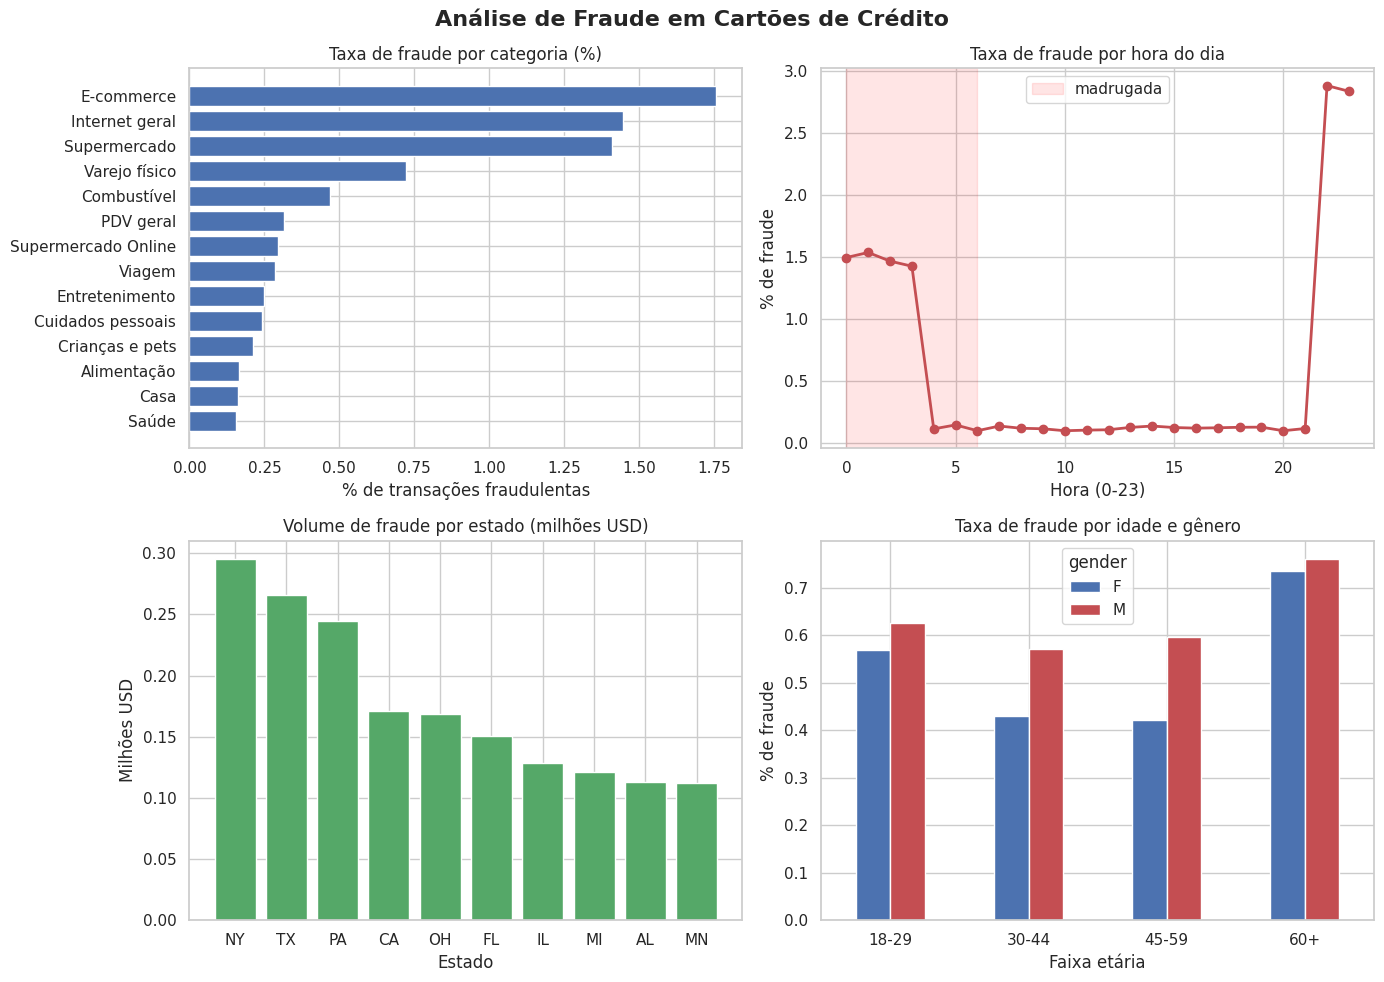

Relatório salvo.


In [29]:
## Converte agregações para Pandas para plotar — apenas as agregações

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Análise de Fraude em Cartões de Crédito", fontsize=16, fontweight="bold")

## Gráfico 1: Taxa de fraude categoria
cat_pd = fraud_by_category.toPandas().sort_values("fraud_rate_pct", ascending=True)
axes[0, 0].barh(cat_pd["category_label"], cat_pd["fraud_rate_pct"], color="#4C72B0")
axes[0, 0].set_title("Taxa de fraude por categoria (%)")
axes[0, 0].set_xlabel("% de transações fraudulentas")

## Gráfico 2: Fraude hora do dia
hour_pd = fraud_by_hour.toPandas()
axes[0, 1].plot(hour_pd["trans_hour"], hour_pd["fraud_rate_pct"],
                marker="o", color="#C44E52", linewidth=2)
axes[0, 1].set_title("Taxa de fraude por hora do dia")
axes[0, 1].set_xlabel("Hora (0-23)")
axes[0, 1].set_ylabel("% de fraude")
axes[0, 1].axvspan(0, 6, alpha=0.1, color="red", label="madrugada")
axes[0, 1].legend()

## Gráfico 3: Volume financeiro fraude estado (top 10)
state_pd = fraud_by_state.toPandas().head(10)
axes[1, 0].bar(state_pd["state"], state_pd["total_fraud_usd"] / 1e6, color="#55A868")
axes[1, 0].set_title("Volume de fraude por estado (milhões USD)")
axes[1, 0].set_xlabel("Estado")
axes[1, 0].set_ylabel("Milhões USD")

## Gráfico 4: Taxa de fraude faixa etária gênero
demo_pd = fraud_by_demo.toPandas()
pivot = demo_pd.pivot(index="age_group", columns="gender", values="fraud_rate_pct")
pivot.plot(kind="bar", ax=axes[1, 1], color=["#4C72B0", "#C44E52"])
axes[1, 1].set_title("Taxa de fraude por idade e gênero")
axes[1, 1].set_xlabel("Faixa etária")
axes[1, 1].set_ylabel("% de fraude")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("/home/jovyan/output/fraud_analysis_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("Relatório salvo.")

In [31]:

## Apresentação dados em linguagem negócio

total_trans    = df_windowed.count()
total_fraud    = df_windowed.filter(F.col("is_fraud") == 1).count()
total_fraud_usd = (
    df_windowed
    .filter(F.col("is_fraud") == 1)
    .agg(F.round(F.sum("amt"), 2).alias("total"))
    .collect()[0]["total"]
)
top_category = fraud_by_category.first()["category_label"]
peak_hour = (
    fraud_by_hour
    .orderBy(F.desc("fraud_rate_pct"))
    .first()["trans_hour"]
)

print("=" * 55)
print("  SUMÁRIO EXECUTIVO — ANÁLISE DE FRAUDE")
print("=" * 55)
print(f"  Total de transações analisadas : {total_trans:>12,}")
print(f"  Transações fraudulentas        : {total_fraud:>12,}")
print(f"  Taxa de fraude global          : {total_fraud/total_trans*100:>11.3f}%")
print(f"  Volume financeiro de fraude    : ${total_fraud_usd:>11,.2f}")
print(f"  Categoria de maior risco       : {top_category}")
print(f"  Hora de pico da fraude         : {peak_hour}h")
print("=" * 55)
print()
print("  RECOMENDAÇÕES:")
print(f"  1. Reforçar autenticação em transações de '{top_category}'")
print(f"  2. Monitoramento intensivo das {peak_hour}h às {(peak_hour+2)%24}h")
print("  3. Alertas para variações > 300% no valor médio por cartão")
print("  4. Revisar transações com dist_km > 500 km")
print("=" * 55)

  SUMÁRIO EXECUTIVO — ANÁLISE DE FRAUDE
  Total de transações analisadas :    1,296,675
  Transações fraudulentas        :        7,506
  Taxa de fraude global          :       0.579%
  Volume financeiro de fraude    : $3,988,088.61
  Categoria de maior risco       : E-commerce
  Hora de pico da fraude         : 22h

  RECOMENDAÇÕES:
  1. Reforçar autenticação em transações de 'E-commerce'
  2. Monitoramento intensivo das 22h às 0h
  3. Alertas para variações > 300% no valor médio por cartão
  4. Revisar transações com dist_km > 500 km
